# Plotting in Pandas

Pandas includes methods for DataFrame and Series objects that are relatively high-level, and that make reasonable assumptions about how the plot should look.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set some Pandas options
# pd.set_option('display.notebook_repr_html', False)
# pd.set_option('display.max_columns', 20)
# pd.set_option('display.max_rows', 25)

In [2]:
normals = pd.Series(np.random.normal(size=10))
normals

0   -0.758814
1   -1.145523
2   -0.330566
3   -1.012589
4    0.123367
5   -1.196274
6    1.059056
7   -0.246015
8    0.200200
9    0.491552
dtype: float64

<Axes: >

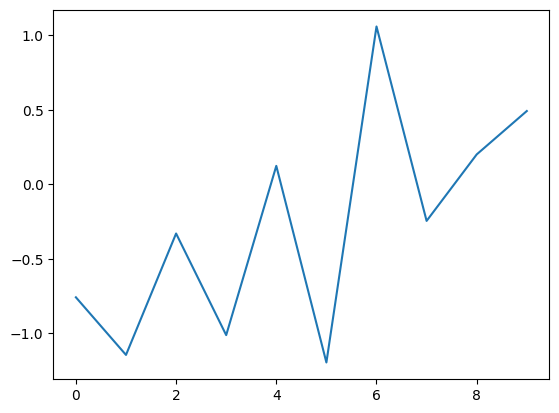

In [3]:
normals.plot()

For a dataframe

In [4]:
variables = pd.DataFrame({'normal': np.random.normal(size=100), 
                       'gamma': np.random.gamma(1, size=100), 
                       'poisson': np.random.poisson(size=100)})
variables

,normal,gamma,poisson
0,-0.219884,0.045360,1
1,-1.384012,0.907800,1
2,-1.013240,0.014162,1
3,-0.533536,1.417873,1
4,0.919448,0.551759,0
...,...,...,...
95,-0.242128,0.907708,2
96,-0.735051,1.521306,1
97,-2.062053,1.034886,0
98,2.988972,1.464362,1


In [5]:
variables.cumsum(0) # axis=0

,normal,gamma,poisson
0,-0.219884,0.045360,1
1,-1.603896,0.953160,2
2,-2.617136,0.967322,3
3,-3.150672,2.385195,4
4,-2.231224,2.936953,4
...,...,...,...
95,-2.256532,96.334820,97
96,-2.991584,97.856125,98
97,-5.053637,98.891011,98
98,-2.064665,100.355374,99


<Axes: >

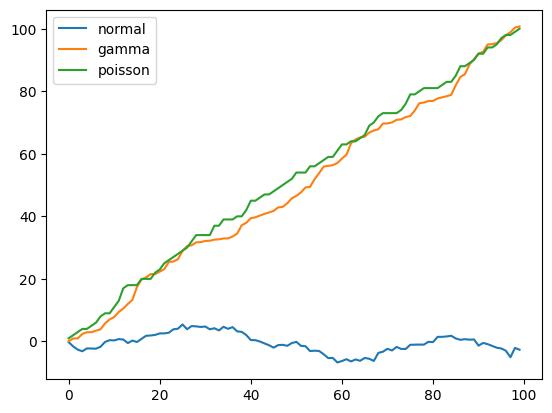

In [6]:
variables.cumsum(0).plot()

As an illustration of the high-level nature of Pandas plots, we can split multiple series into subplots with a single argument for plot:

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

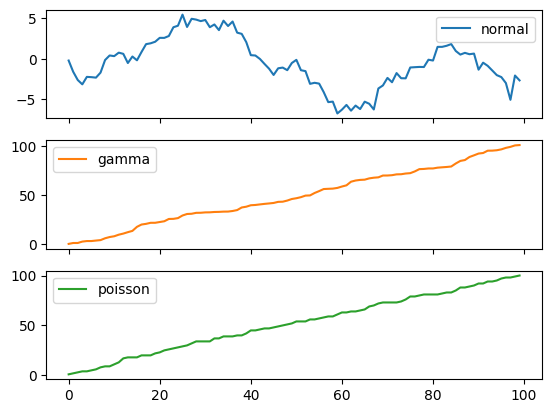

In [7]:
variables.cumsum(0).plot(subplots=True)

Or, we may want to have some series displayed on the secondary y-axis, which can allow for greater detail and less empty space:


<Axes: >

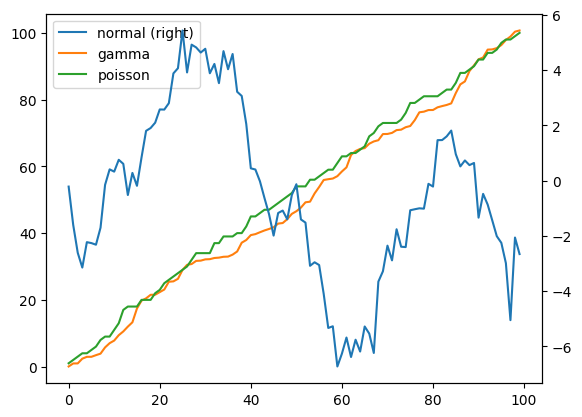

In [8]:
variables.cumsum(0).plot(secondary_y='normal')

If we would like a little more control, we can use matplotlib's subplots function directly, and manually assign plots to its axes:

Text(0, 0.5, 'cumulative sum')

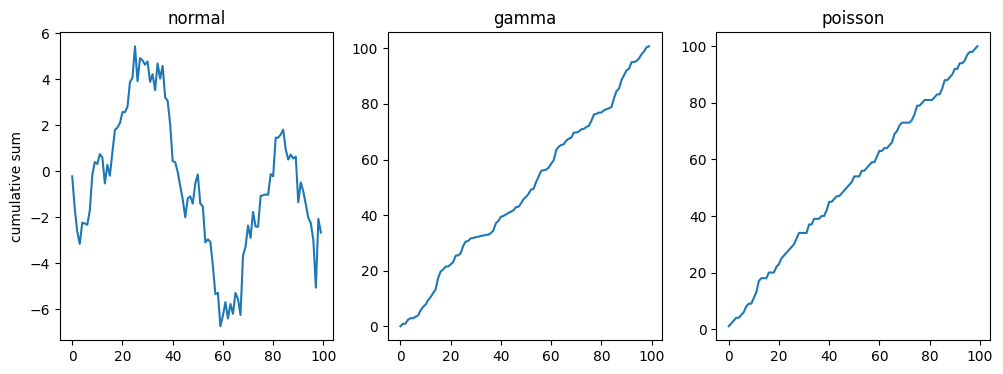

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
for i,var in enumerate(['normal','gamma','poisson']):
    variables[var].cumsum(0).plot(ax=axes[i], title=var)
axes[0].set_ylabel('cumulative sum')

For labeled, time series data, you may wish to produce a bar plot:

In [10]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range('1/1/2000', periods=1000))
ts = ts.cumsum()
ts

2000-01-01    -0.850918
2000-01-02    -3.578552
2000-01-03    -4.234107
2000-01-04    -5.180819
2000-01-05    -5.372858
                ...    
2002-09-22   -49.348951
2002-09-23   -49.637897
2002-09-24   -49.641191
2002-09-25   -48.595384
2002-09-26   -47.840654
Freq: D, Length: 1000, dtype: float64

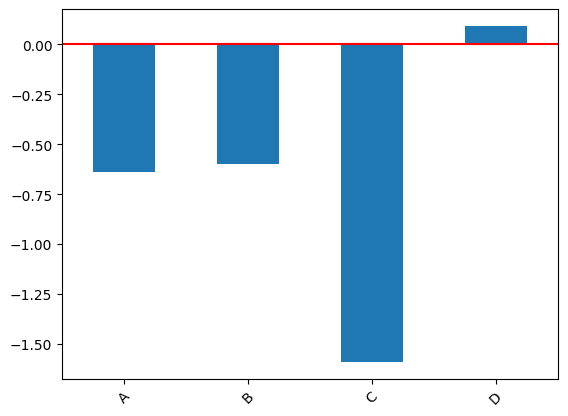

In [11]:
df = pd.DataFrame(np.random.randn(1000, 4), index=pd.date_range('1/1/2000', periods=1000), columns=list('ABCD'))
# Use loc to select the row with index label '5'
row_5 = df.iloc[5]
# Plot the selected row
row_5.plot(kind='bar', rot=45)
plt.axhline(0, color='r')
plt.show()

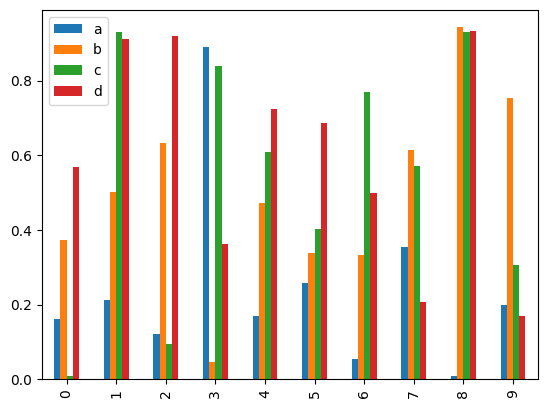

In [12]:
df2 = pd.DataFrame(np.random.rand(10, 4), columns=['a', 'b', 'c', 'd'])
df2.plot(kind='bar', rot=90);

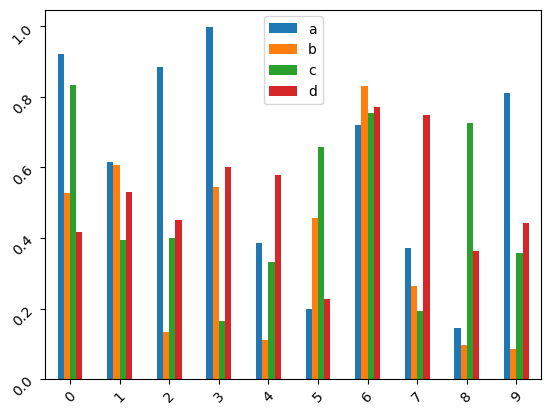

In [13]:
df2 = pd.DataFrame(np.random.rand(10, 4), columns=['a', 'b', 'c', 'd'])
df2.plot(kind='bar')
plt.xticks(rotation=45)  # Adjust the rotation angle as needed
plt.yticks(rotation=45)  # Adjust the rotation angle as needed
plt.show()

#### Stacked

In [14]:
df2

,a,b,c,d
0,0.920409,0.526070,0.832521,0.415430
1,0.614252,0.607320,0.394202,0.529602
2,0.883054,0.132474,0.399346,0.450097
3,0.997457,0.544725,0.164061,0.601001
4,0.386817,0.110079,0.330872,0.578389
5,0.198335,0.455375,0.657093,0.227959
6,0.718740,0.829230,0.753765,0.771395
7,0.371284,0.262559,0.193296,0.749147
8,0.144568,0.096264,0.724879,0.362301
9,0.812006,0.085500,0.357710,0.443269


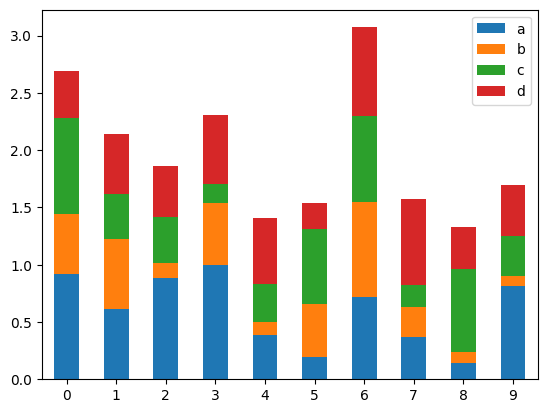

In [15]:
df2.plot(kind='bar', stacked=True, rot=0);

#### Histogram

In Matplotlib, the default behavior for choosing the number of bins in a histogram is based on the Freedman-Diaconis rule.

<Axes: ylabel='Frequency'>

<Figure size 640x480 with 0 Axes>

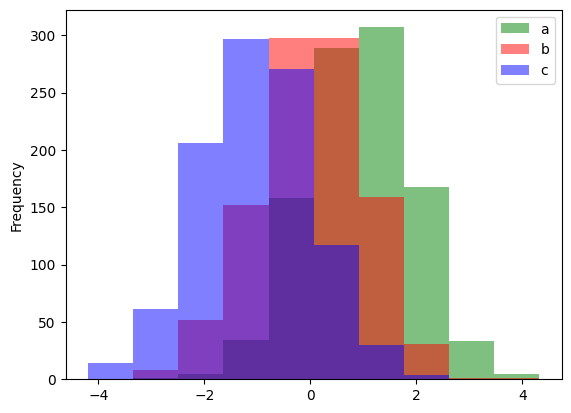

In [16]:
df4 = pd.DataFrame({'a': np.random.randn(1000) + 1, 'b': np.random.randn(1000), 'c': np.random.randn(1000) - 1}, columns=['a', 'b', 'c'])
plt.figure()
colors = ['green', 'red', 'blue']
df4.plot(kind='hist',color = colors, alpha=.5)

Text(0, 0.5, 'Frequency')

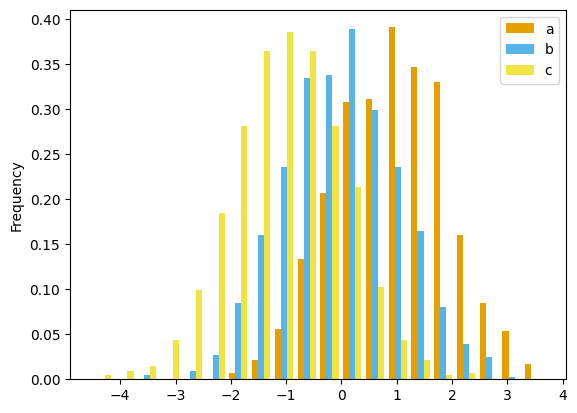

In [17]:
df4 = pd.DataFrame({'a': np.random.randn(1000) + 1, 'b': np.random.randn(1000), 'c': np.random.randn(1000) - 1}, columns=['a', 'b', 'c'])

# Make a separate list for each airline
x1 = list(df4['a'])
x2 = list(df4['b'])
x3 = list(df4['c'])

# Assign colors for each airline and the names
colors = ['#E69F00', '#56B4E9', '#F0E442']
names = ['a', 'b', 'c']

# Make the histogram using a list of lists
plt.hist([x1, x2, x3], bins = 20, density=True,
         color = colors, label=names)

# Plot formatting
plt.legend()
plt.ylabel('Frequency')

<Axes: ylabel='Frequency'>

<Figure size 640x480 with 0 Axes>

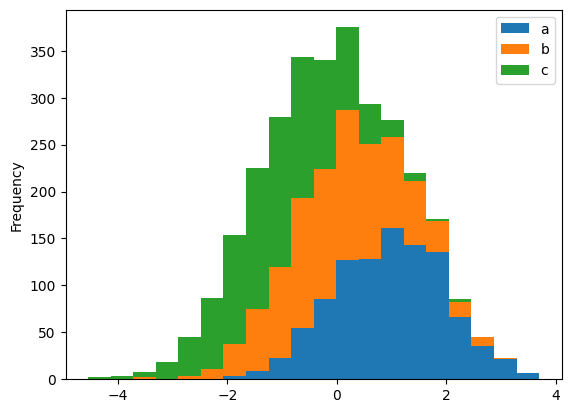

In [18]:
plt.figure()

df4.plot(kind='hist', stacked=True, bins=20)

#### Box Plots

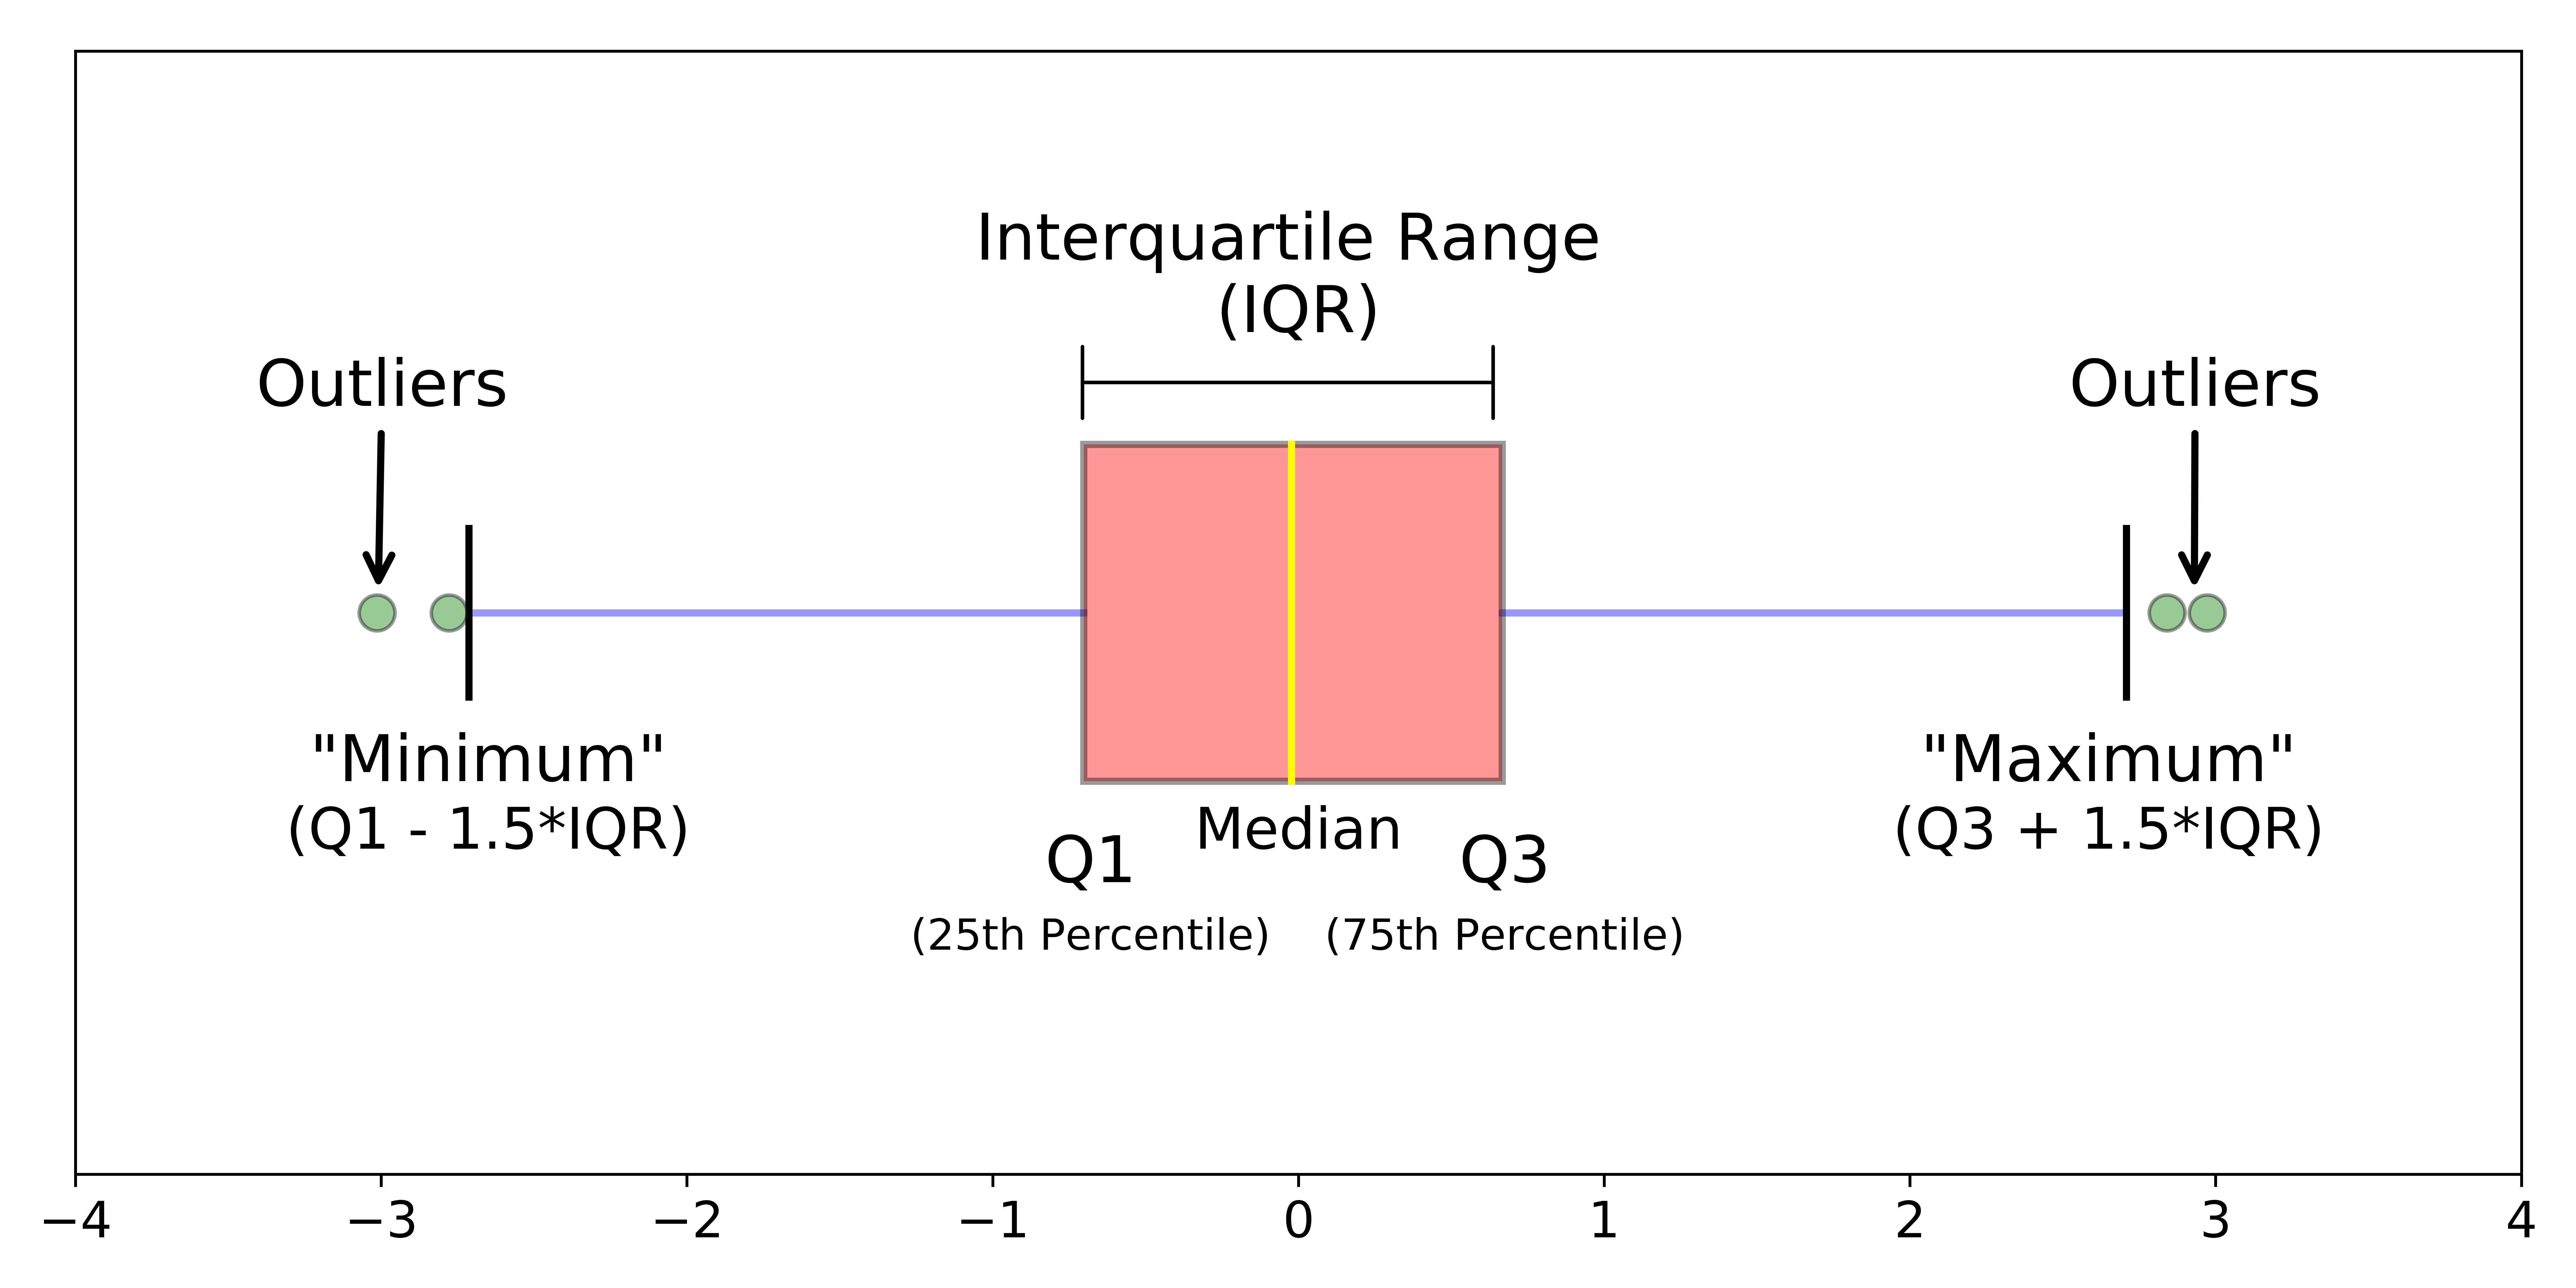

In [19]:
from IPython.display import Image
display(Image(filename='Box-Plot-and-Whisker-Plot.png'))

<Axes: >

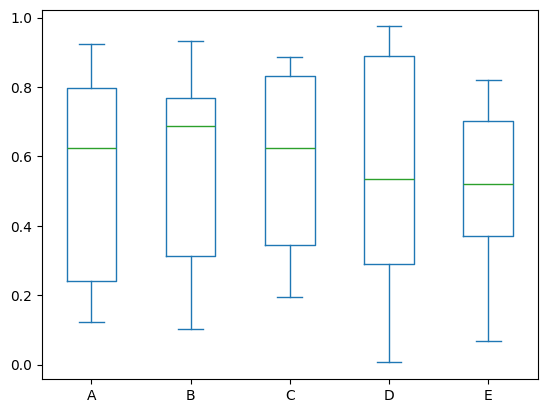

In [20]:
df = pd.DataFrame(np.random.rand(10, 5), columns=['A', 'B', 'C', 'D', 'E'])
df.plot(kind='box')

In [21]:
df.describe()

,A,B,C,D,E
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,0.549726,0.574790,0.586970,0.533129,0.494643
std,0.311580,0.316161,0.261318,0.374872,0.248131
min,0.122368,0.101301,0.194729,0.006173,0.067972
25%,0.241719,0.312877,0.343571,0.288841,0.371597
50%,0.623533,0.687957,0.624694,0.536218,0.519625
75%,0.798463,0.769805,0.832367,0.888554,0.701577
max,0.924153,0.931826,0.887774,0.974589,0.819798


In [22]:
df

,A,B,C,D,E
0,0.122368,0.101301,0.887774,0.413666,0.551656
1,0.204721,0.559692,0.857531,0.934621,0.539178
2,0.290611,0.663799,0.491721,0.012934,0.188217
3,0.668958,0.728668,0.756878,0.810861,0.067972
4,0.225422,0.931826,0.294187,0.006173,0.767444
5,0.812578,0.230605,0.194729,0.275069,0.500073
6,0.914221,0.783517,0.653205,0.658769,0.751551
7,0.756118,0.112708,0.278707,0.330154,0.362924
8,0.924153,0.923671,0.596183,0.974589,0.397615
9,0.578109,0.712116,0.858788,0.914452,0.819798


In [23]:
df['D'].median()

0.5362177474013973

In [24]:
df['D'].quantile(0.75)

0.8885541961371601

In [25]:
df['D'].quantile(0.25)

0.28884055552996446

In [26]:
df['D'].quantile(0.25) - (1.5*(df['D'].quantile(0.75) - df['D'].quantile(0.25)))

-0.610729905380829

In [27]:
df['D'].min()

0.006173424877613742

In [28]:
df['D'].quantile(0.75) + (1.5*(df['D'].quantile(0.75) - df['D'].quantile(0.25)))

1.7881246570479536

In [29]:
df['D'].max()

0.974589410247346

#### Area

          a         b         c         d
0  0.572328  0.046787  0.154932  0.817874
1  0.254685  0.199891  0.687117  0.148144
2  0.712327  0.674451  0.952465  0.907754
3  0.641938  0.889029  0.861687  0.397535
4  0.290413  0.824299  0.252177  0.355689
5  0.100390  0.682600  0.778492  0.961347
6  0.246704  0.077577  0.834673  0.400268
7  0.884967  0.940839  0.760714  0.276836
8  0.942820  0.548053  0.039704  0.091789
9  0.652286  0.375663  0.889941  0.553056


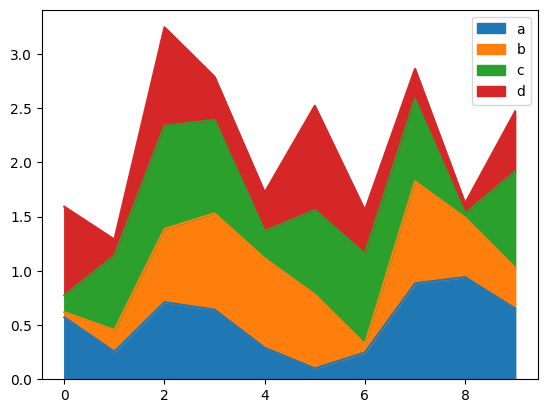

In [30]:
df = pd.DataFrame(np.random.rand(10, 4), columns=['a', 'b', 'c', 'd'])
print(df)
df.plot(kind='area');

#### Scatter

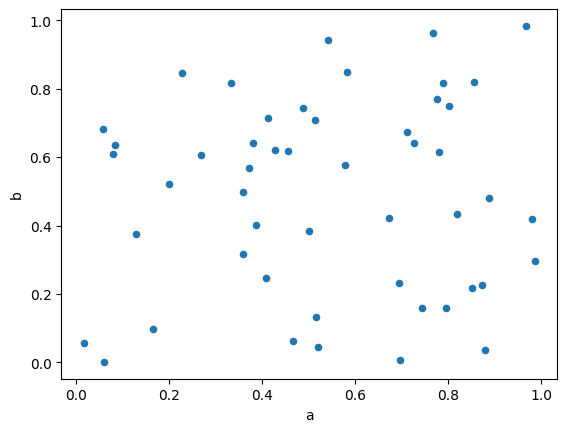

In [31]:
df = pd.DataFrame(np.random.rand(50, 4), columns=['a', 'b', 'c', 'd'])

df.plot(kind='scatter', x='a', y='b');

#### Pie

array([<Axes: ylabel='x'>, <Axes: ylabel='y'>], dtype=object)

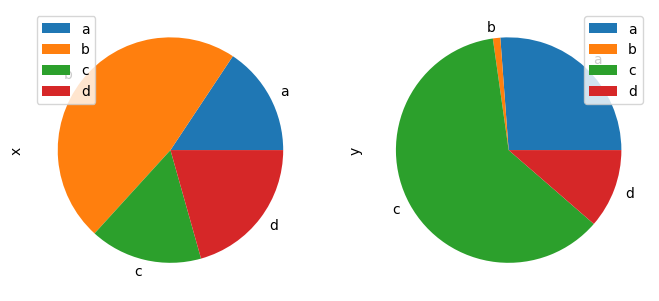

In [32]:
df = pd.DataFrame(3 * np.random.rand(4, 2), index=['a', 'b', 'c', 'd'], columns=['x', 'y'])

df.plot(kind='pie', subplots=True, figsize=(8, 4))

#### Kernel Density Estimation - KDE. The KDE plot provides an estimate of the probability density function (PDF) of the data.

<Axes: ylabel='Density'>

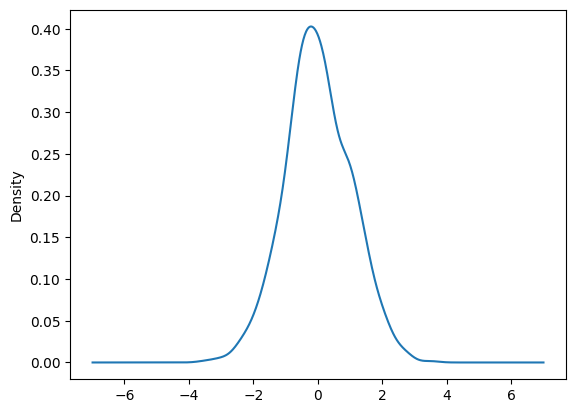

In [33]:
ser = pd.Series(np.random.randn(1000))

ser.plot(kind='kde')

#### Histogram with KDE

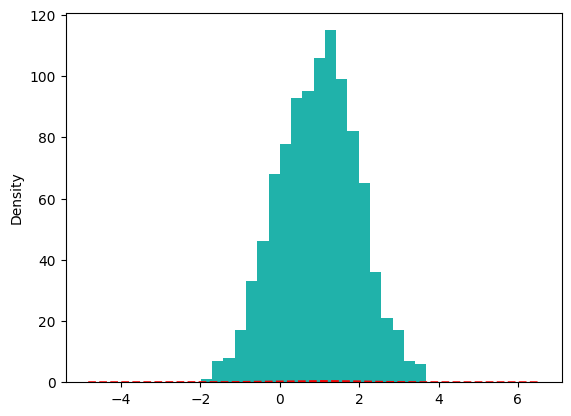

In [34]:
df4['a'].hist(bins=20, color='lightseagreen')
df4['a'].plot(kind='kde', style='r--')
plt.show()

#### Scatter Matrix

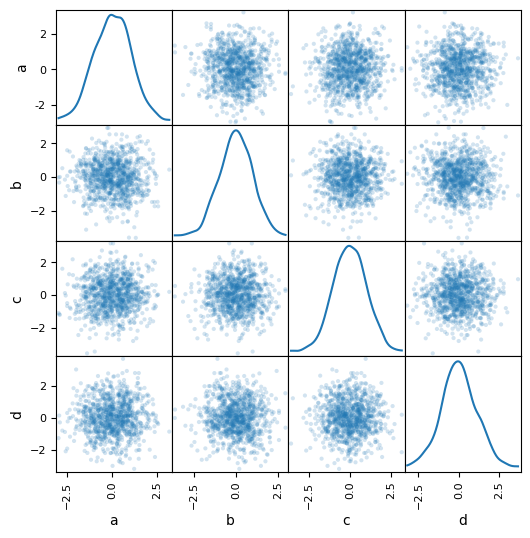

In [35]:
from pandas.plotting import scatter_matrix

df = pd.DataFrame(np.random.randn(1000, 4), columns=['a', 'b', 'c', 'd'])

scatter_matrix(df, alpha=0.2, figsize=(6, 6), diagonal='kde')
plt.show()

## I. Plotting with plotly

Plotly is collaborative, makes beautiful interactive graphs with a URL for you, and stores your data and graphs together. This NB shows how to use Plotly to share plots from some awesome Python plotting libraries. 

For best results, you can copy and paste this Notebook and key. Run `$ pip install plotly` inside a terminal then start up a Notebook. We'll also be using ggplot, seaborn, and prettyplotlib, which you can also all install form pip. Let's get started.

### Plotly inside jupyter_lab

In [37]:
import plotly.express as px
fig = px.bar(x=["a", "b", "c"], y=[1, 3, 2])
fig.show()

In [38]:
import plotly.express as px
fig = px.line(x=["a", "b", "c"], y=[1, 3, 2])
fig.show()

### Plotly in chart_studio

In [39]:
%matplotlib inline
import matplotlib.pyplot as plt # side-stepping mpl backend
import matplotlib.gridspec as gridspec # subplots
import numpy as np

You can use our public key and username or sign up for an account on [Plotly](plot.ly/ssi). Plotly is free for public use, you own your data, and you control the privacy. 

In [40]:
import chart_studio.plotly as py
import chart_studio.tools as tls
from plotly.graph_objs import *

# Replace 'username' and 'key' with your actual Plotly username and API key
username = 'smlecture.education'
key = 'B1ytjTbQ8yS0Yz7mH1ty'

py.sign_in(username, key)

In [41]:
tls.set_credentials_file(username, key)
# tls.get_credentials_file()

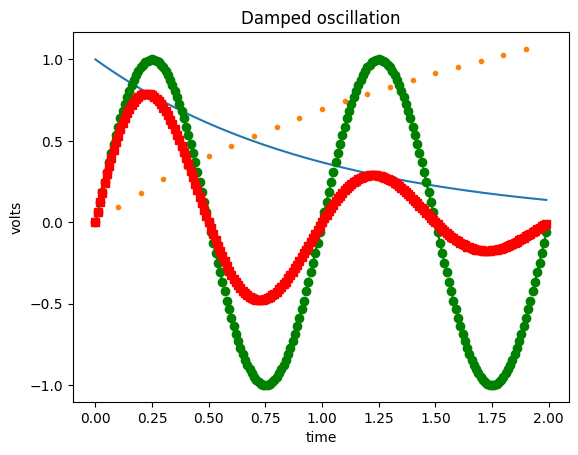

In [42]:
fig1 = plt.figure()
# Make a legend for specific lines.
import matplotlib.pyplot as plt
import numpy as np

t1 = np.arange(0.0, 2.0, 0.1)
t2 = np.arange(0.0, 2.0, 0.01)

# note that plot returns a list of lines.  The "l1, = plot" usage
# extracts the first element of the list into l1 using tuple
# unpacking.  So l1 is a Line2D instance, not a sequence of lines
l1, = plt.plot(t2, np.exp(-t2))
l2, l3 = plt.plot(t2, np.sin(2 * np.pi * t2), '--go', t1, np.log(1 + t1), '.')
l4, = plt.plot(t2, np.exp(-t2) * np.sin(2 * np.pi * t2), 'rs-.')

plt.xlabel('time')
plt.ylabel('volts')
plt.title('Damped oscillation')

plt.show()

Now, to convert it to a Plotly figure, this is all it takes:

In [43]:
py.iplot_mpl(fig1)

You can hover, zoom, and pan on the figure. You can also strip out the matplotlib styling, and use Plotly's default styling.

In [44]:
fig2 = plt.figure()

from pylab import *

def f(t):
    'a damped exponential'
    s1 = cos(2*pi*t)
    e1 = exp(-t)
    return multiply(s1,e1)

t1 = arange(0.0, 5.0, .2)


l = plot(t1, f(t1), 'ro')
setp(l, 'markersize', 30)
setp(l, 'markerfacecolor', 'b')

py.iplot_mpl(fig2)

You can get the data from any Plotly graph. That means you can re-plot the graph or part of it, or use your favorite Python tools to wrangle and analyze your data. Check out the [getting started guide](http://nbviewer.ipython.org/github/plotly/python-user-guide/blob/master/s0_getting-started/s0_getting-started.ipynb) for a full background on these features.

You can also plot with Plotly with pandas, NumPy, datetime, and more of your favorite Python tools. We've already imported numpy and matplotlib; here we've kept them in so you can simply copy and paste these examples into your own NB. 

In [42]:
fig3 = plt.figure()

import numpy as np
import matplotlib.pyplot as plt

# make a little extra space between the subplots
plt.subplots_adjust(wspace=0.5)

dt = 0.01
t = np.arange(0, 30, dt)
nse1 = np.random.randn(len(t))                 # white noise 1
nse2 = np.random.randn(len(t))                 # white noise 2
r = np.exp(-t/0.05)

cnse1 = np.convolve(nse1, r, mode='same')*dt   # colored noise 1
cnse2 = np.convolve(nse2, r, mode='same')*dt   # colored noise 2

# two signals with a coherent part and a random part
s1 = 0.01*np.sin(2*np.pi*10*t) + cnse1
s2 = 0.01*np.sin(2*np.pi*10*t) + cnse2

plt.subplot(211)
plt.plot(t, s1, 'b-', t, s2, 'g-')
plt.xlim(0,5)
plt.xlabel('time')
plt.ylabel('s1 and s2')
plt.grid(True)

plt.subplot(212)
cxy, f = plt.csd(s1, s2, 256, 1./dt)
plt.ylabel('CSD (db)')

py.iplot_mpl(fig3)

/home/smadmin/anaconda3/lib/python3.11/site-packages/plotly/matplotlylib/renderer.py:647: UserWarning:

Looks like the annotation(s) you are trying 
to draw lies/lay outside the given figure size.

Therefore, the resulting Plotly figure may not be 
large enough to view the full text. To adjust 
the size of the figure, use the 'width' and 
'height' keys in the Layout object. Alternatively,
use the Margin object to adjust the figure's margins.



Another subplotting example using Plotly's defaults. 

In [46]:
fig4 = plt.figure()

from pylab import figure, show
from numpy import arange, sin, pi

t = arange(0.0, 1.0, 0.01)

fig = figure(1)

ax1 = fig.add_subplot(211)
ax1.plot(t, sin(2*pi*t))
ax1.grid(True)
ax1.set_ylim( (-2,2) )
ax1.set_ylabel('1 Hz')
ax1.set_title('A sine wave or two')

for label in ax1.get_xticklabels():
    label.set_color('orange')


ax2 = fig.add_subplot(212)
ax2.plot(t, sin(2*2*pi*t))
ax2.grid(True)
ax2.set_ylim( (-2,2) )
l = ax2.set_xlabel('Hi mom')
l.set_color('g')
l.set_fontsize('large')
plt.tight_layout()

py.iplot_mpl(fig4, strip_style = True)

### Plotly charts in Dash

In [47]:
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go

app = Dash(__name__)


app.layout = html.Div([
    html.H4('Interactive color selection with simple Dash example'),
    html.P("Select color:"),
    dcc.Dropdown(
        id="dropdown",
        options=['Gold', 'MediumTurquoise', 'LightGreen'],
        value='Gold',
        clearable=False,
    ),
    dcc.Graph(id="graph"),
])


@app.callback(
    Output("graph", "figure"), 
    Input("dropdown", "value"))
def display_color(color):
    fig = go.Figure(
        data=go.Bar(y=[2, 3, 1], # replace with your own data source
                    marker_color=color))
    return fig


app.run_server(debug=True)

## II. Plotting with seaborn

Another library we really dig is [seaborn](http://stanford.edu/~mwaskom/software/seaborn/index.html), a library to maximize aesthetics of matplotlib plots. It's by [Michael Waskom](http://stanford.edu/~mwaskom/). You'll need to install it with ` $ pip install seaborn`, and may need to [import six](http://stackoverflow.com/questions/13967428/importerror-no-module-named-six), which you can do from pip. The styling isn't yet translated to Plotly, so we'll go to Plotly's default settings. 

In [45]:
import seaborn as sns

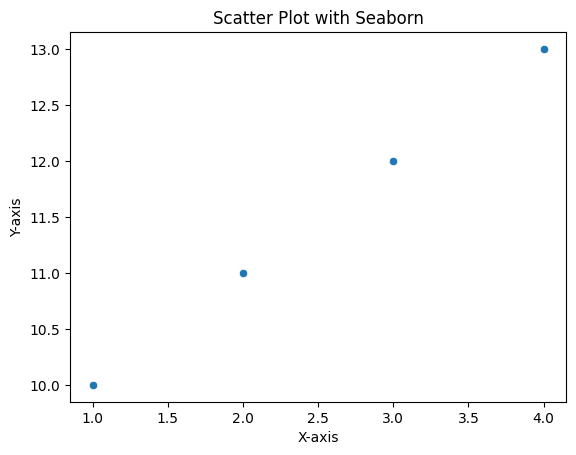

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
x = [1, 2, 3, 4]
y = [10, 11, 12, 13]

# Create a scatter plot using Seaborn
sns.scatterplot(x=x, y=y)
plt.title('Scatter Plot with Seaborn')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

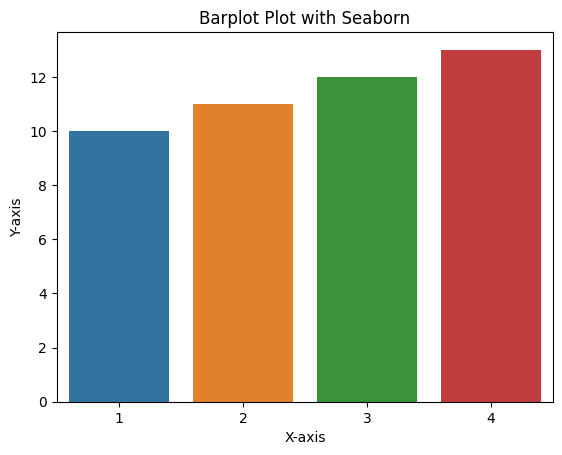

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
x = [1, 2, 3, 4]
y = [10, 11, 12, 13]

sns.barplot(x=x, y=y)
plt.title('Barplot Plot with Seaborn')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [51]:
def sinplot(flip=1):
    x = np.linspace(0, 14, 100)
    for i in range(1, 7):
        plt.plot(x, np.sin(x + i * .5) * (7 - i) * flip)

In [52]:
fig14 = plt.figure()

sns.set_style("dark")
sinplot()

py.iplot_mpl(fig14, strip_style = True)

You can also run subplots like this.

In [53]:
fig15 = plt.figure()

with sns.axes_style("darkgrid"):
    plt.subplot(211)
    sinplot()
    plt.subplot(212)
    sinplot(-1)

py.iplot_mpl(fig15, strip_style = True)

And a final example, [combining plot types](http://stanford.edu/~mwaskom/software/seaborn/tutorial/plotting_distributions.html#basic-visualization-with-histograms).

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.random import randn
import chart_studio.plotly as py

# Your original code using distplot
sns.set_palette("hls")
mpl.rc("figure", figsize=(8, 4))
data = randn(200)

sns.displot(data, kde=True)
# Convert the matplotlib figure to a plotly figure
fig16 = plt.gcf()
py.iplot_mpl(fig16, strip_style=True)